# Modeling

本ノートブックでは、前処理・特徴量生成を適用したデータに対して複数の回帰モデルを比較し、提出候補となる単体モデルを選定する。   

House Prices は数値・カテゴリが混在する表形式データであり、非線形な関係や特徴量間の相互作用を含みやすい。

一方で、目的変数を `log1p` 変換しているため、線形モデルが安定した予測を返す可能性もある。  
そのため、**異なる仮定を持つモデル群を並列に評価**し、単体性能だけでなく後続のアンサンブル候補としての価値も確認する。

| 系統 | モデル | 役割 |
|---|---|---|
| 木系モデル | LightGBM / XGBoost / CatBoost | 主力候補 |
| 線形モデル | Ridge / Lasso / ElasticNet | 比較軸・補完候補 |

In [1]:
import sys
import warnings

sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler

from src.preprocessing import impute_missing, convert_types
from src.features import add_features, add_neighborhood_features, add_target_encoding_features, FEATURES
from src.utils import run_cv, make_submission, seed_everything

SEED = 123
seed_everything(SEED)

## 1. データ準備

各モデルで比較可能な入力を作るため、前処理・特徴量生成・エンコーディングを行う。  
この段階で `X_train`, `y_train`, `X_test` を作成し、以降のモデル比較では共通の入力を用いる。

In [2]:
train_df = pd.read_csv("../data/train.csv")
test_df  = pd.read_csv("../data/test.csv")

y = train_df["SalePrice"]
train_df = train_df.drop("SalePrice", axis=1)

df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

In [3]:
# 前処理
df = impute_missing(df)
df = convert_types(df)

In [4]:
# 特徴量生成
df = add_features(df)

train = df.iloc[:len(y)].copy()
test  = df.iloc[len(y):].copy()

train = add_neighborhood_features(train, train)
test  = add_neighborhood_features(test, train)

# KFold Target Encoding
train["SalePrice"] = y.values
train, test = add_target_encoding_features(train, test, target_col="SalePrice")
train = train.drop("SalePrice", axis=1)

X_train = train[FEATURES]
y_train = np.log1p(y)
X_test  = test[FEATURES]

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

X_train: (1460, 45)
X_test:  (1459, 45)


## 2. LightGBM

LightGBM は、表形式データにおいて**性能・計算効率・扱いやすさのバランスが良く、比較の基準線として置きやすい**。  
元特徴量に加えて手作り特徴量やカテゴリ由来の情報が混在する構成では、非線形な関係や特徴量間の相互作用を捉えやすい木系モデルが有力候補になると考えた。  

また、LightGBM は特徴量重要度も確認しやすいため、CV スコアだけでなく、予測に寄与した特徴もあわせて把握できる。  
単体提出候補として評価するとともに、後続のモデル比較やアンサンブル設計の起点として用いる。

※ Optunaセルは実行に数分〜数十分かかるためスキップ可。結果のベストパラメータは次のセルにハードコードしてある。

In [ ]:
# Optuna で 100 trial 探索し、最適パラメータを決定する。
def objective_lgb(trial):
    params = {
        "boosting_type"  : "gbdt",
        "objective"      : "regression",
        "metric"         : "rmse",
        "random_state"   : SEED,
        "importance_type": "gain",
        "n_estimators"   : 100000,
        "learning_rate"  : trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves"     : trial.suggest_int("num_leaves", 8, 64),
        "max_depth"      : trial.suggest_int("max_depth", 3, 7),
        "lambda_l1"      : trial.suggest_float("lambda_l1", 0.0, 1.0),
        "lambda_l2"      : trial.suggest_float("lambda_l2", 0.0, 1.0),
    }
    metrics, _ = run_cv(lgb.LGBMRegressor(**params), X_train, y_train, random_state=SEED)
    return metrics[:, 2].mean()

study_lgb = optuna.create_study(direction="minimize")
study_lgb.optimize(objective_lgb, n_trials=100)

print("best val RMSE:", study_lgb.best_value)
print("best params:", study_lgb.best_params)

### 2.1 最適パラメータでの学習・評価

探索で得られたパラメータを固定し、5-Fold CV で汎化性能と特徴量重要度を確認する。 

In [ ]:
params_lgb = {
    "boosting_type"  : "gbdt",
    "objective"      : "regression",
    "metric"         : "rmse",
    "random_state"   : SEED,
    "importance_type": "gain",
    "n_estimators"   : 100000,
    "learning_rate"  : 0.0283,
    "num_leaves"     : 53,
    "max_depth"      : 3,
    "lambda_l1"      : 0.0286,
    "lambda_l2"      : 0.192,
}

lgb_model = lgb.LGBMRegressor(**params_lgb)
metrics_lgb, imp_lgb = run_cv(lgb_model, X_train, y_train, random_state=SEED)

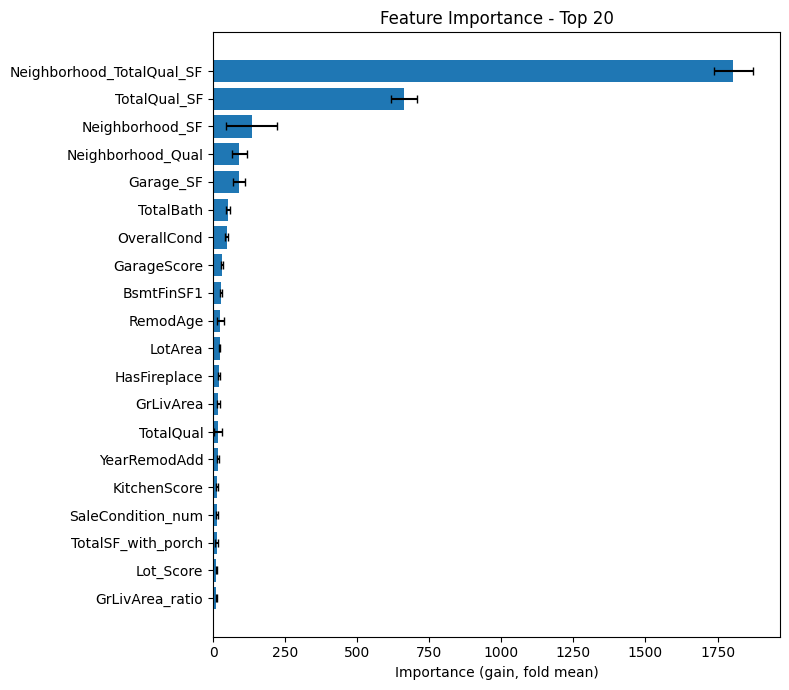

In [7]:
# 特徴量重要度 上位20件 棒グラフ
top20 = imp_lgb.head(20).sort_values("imp")

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20.index, top20["imp"], xerr=top20["imp_std"], capsize=3)
ax.set_xlabel("Importance (gain, fold mean)")
ax.set_title("Feature Importance - Top 20")
plt.tight_layout()
plt.show()

上位を品質×面積の交互作用特徴量（`Neighborhood_TotalQual_SF`, `TotalQual_SF`）が占めており、単体の特徴量よりも組み合わせた特徴量の方が予測に強く寄与していることが分かる。  
また、Target Encoding 由来の Neighborhood 系特徴量（`Neighborhood_SF`, `Neighborhood_Qual`）が上位に入っており、立地情報の数値化が有効に機能している。

### 2.2 全データで再学習 → 提出ファイル生成

CVはあくまで性能推定のためであり、提出用モデルは全データで学習する。

In [ ]:
# 全データで再学習 → submission
lgb_model_full = lgb.LGBMRegressor(**params_lgb)
lgb_model_full.fit(X_train, y_train)

make_submission(
    lgb_model_full, X_test, test["Id"],
    filepath="../submissions/submission_04_lgb_baseline.csv"
)

## 3. XGBoost

XGBoost は、LightGBM と近い木系モデルに属するが、分割や正則化の挙動が異なるため、別の比較対象として評価する。  

単体性能の比較に加え、予測傾向の差が後続のアンサンブルで補完的に働く可能性もあるため、LightGBM の代替ではなく、**別の木系候補**として位置づける。

In [8]:
# XGBoost用にcategory型を数値に変換
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

for col in X_train_xgb.select_dtypes(include="category").columns:
    X_train_xgb[col] = X_train_xgb[col].cat.codes
    X_test_xgb[col] = X_test_xgb[col].cat.codes

### 3.1 最適パラメータでの学習・評価 → 提出ファイル生成

In [ ]:
# Optuna で 50 trial 探索し、最適パラメータを決定する。
def objective_xgb(trial):
    params = {
        "objective"        : "reg:squarederror",
        "eval_metric"      : "rmse",
        "random_state"     : SEED,
        "n_estimators"     : 1000,
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.1),
        "max_depth"        : trial.suggest_int("max_depth", 3, 7),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 0.0, 1.0),
    }
    metrics, _ = run_cv(xgb.XGBRegressor(**params), X_train_xgb, y_train, random_state=SEED)
    return metrics[:, 2].mean()  # val RMSEの平均

study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=50)

print("best val RMSE:", study_xgb.best_value)
print("best params:", study_xgb.best_params)

In [9]:
params_xgb = {
    "objective"        : "reg:squarederror",
    "eval_metric"      : "rmse",
    "learning_rate"    : 0.011,
    "max_depth"        : 4,
    "n_estimators"     : 1000,
    "random_state"     : SEED,
    "subsample"        : 0.51,
    "colsample_bytree" : 0.55,
    "reg_alpha"        : 0.48,
    "reg_lambda"       : 0.82
}

xgb_model = xgb.XGBRegressor(**params_xgb)
metrics_xgb, imp_xgb = run_cv(xgb_model, X_train_xgb, y_train, random_state=SEED)

[fold 0] tr: 0.07794, va: 0.10709
[fold 1] tr: 0.07522, va: 0.13111
[fold 2] tr: 0.07390, va: 0.12584
[fold 3] tr: 0.07427, va: 0.12873
[fold 4] tr: 0.08230, va: 0.12425
[cv] tr: 0.07673±0.00312, va: 0.12340±0.00849


In [10]:
# 提出用は全データで再学習
xgb_model_full = xgb.XGBRegressor(**params_xgb)
xgb_model_full.fit(X_train_xgb, y_train)

make_submission(
    xgb_model_full, X_test_xgb, test["Id"],
    filepath="../submissions/submission_04_xgb_baseline.csv"
)

Saved: ../submissions/submission_04_xgb_baseline.csv


,Id,SalePrice
1460,1461,125718.304688
1461,1462,162439.312500
1462,1463,184121.718750
1463,1464,187575.859375
1464,1465,188048.000000
...,...,...
2914,2915,79075.242188
2915,2916,81622.898438
2916,2917,163566.187500
2917,2918,118449.906250


## 4. CatBoost

CatBoost は、カテゴリ変数を含む表形式データに強みを持ち、House Prices のようにカテゴリ特徴が多い課題では、LightGBM / XGBoost と異なる予測傾向を持つ可能性がある。  
そのため、単体性能の比較に加え、後続のアンサンブルで残す合理性があるかという観点でも確認する。

### 4.1 最適パラメータでの学習・評価 → 提出ファイル生成

In [ ]:
# Optuna で 50 trial 探索し、最適パラメータを決定する。
def objective_cat(trial):
    params = {
        "loss_function"    : "RMSE",
        "random_seed"      : SEED,
        "iterations"       : 1000,
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.1),
        "depth"            : trial.suggest_int("depth", 3, 7),
        "l2_leaf_reg"      : trial.suggest_float("l2_leaf_reg", 0.0, 1.0),
    }
    metrics, _ = run_cv(CatBoostRegressor(**params), X_train, y_train, random_state=SEED)
    return metrics[:, 2].mean()

study_cat = optuna.create_study(direction="minimize")
study_cat.optimize(objective_cat, n_trials=50)

print("best val RMSE:", study_cat.best_value)
print("best params:", study_cat.best_params)

In [14]:
params_cat = {
    "loss_function"  : "RMSE",     
    "learning_rate"  : 0.022, 
    "depth"          : 7,     
    "iterations"     : 10000, 
    "random_seed"    : SEED,  
    "l2_leaf_reg"    : 0.29,  
    "verbose"        : 0,   
}

cat_model = CatBoostRegressor(**params_cat)
metrics_cat, imp_cat = run_cv(cat_model, X_train, y_train, random_state=SEED)

[fold 0] tr: 0.00834, va: 0.10802
[fold 1] tr: 0.05067, va: 0.11963
[fold 2] tr: 0.01033, va: 0.11868
[fold 3] tr: 0.03517, va: 0.12671
[fold 4] tr: 0.01765, va: 0.11802
[cv] tr: 0.02443±0.01617, va: 0.11821±0.00597


In [15]:
cat_model_full = CatBoostRegressor(**params_cat)
cat_features = [col for col in X_train.columns if X_train[col].dtype.name == "category"]
cat_model_full.fit(X_train, y_train, cat_features=cat_features, verbose=0)

make_submission(
    cat_model_full, X_test, test["Id"],
    filepath="../submissions/submission_04_cat_baseline.csv"
)

Saved: ../submissions/submission_04_cat_baseline.csv


,Id,SalePrice
1460,1461,121906.576340
1461,1462,162518.915113
1462,1463,187121.663454
1463,1464,195493.131635
1464,1465,183745.858270
...,...,...
2914,2915,80506.757046
2915,2916,82708.730414
2916,2917,162256.186282
2917,2918,114975.990807


## 5. 線形モデル（Ridge / Lasso / ElasticNet）

木系モデルに加えて、線形モデルも比較対象に含める。  
目的変数を `log1p` 変換しているため、線形モデルでも一定の安定性が見込める一方、木系とは異なる予測傾向を返す可能性がある。  
そのため、単体性能の比較に加え、アンサンブルにおける補完候補としての価値も確認する。  

線形モデルでは、`pd.get_dummies()` による One-Hot Encoding を行った上で、train / test の列を揃え、必要に応じて 0 で補完した後、`StandardScaler` によりスケーリングを適用した。

木系モデルと同一の前処理を使うのではなく、**各アルゴリズムが妥当に比較できる条件に整えて**評価する。  

In [16]:
# 線形モデル共通: category型をダミー変数に変換
X_train_linear = pd.get_dummies(X_train)
X_test_linear = pd.get_dummies(X_test)

X_train_linear, X_test_linear = X_train_linear.align(X_test_linear, join="left", axis=1, fill_value=0)

X_train_linear = X_train_linear.fillna(0)
X_test_linear = X_test_linear.fillna(0)

scaler = StandardScaler()
X_train_linear = pd.DataFrame(
    scaler.fit_transform(X_train_linear),
    columns=X_train_linear.columns
)
X_test_linear = pd.DataFrame(
    scaler.transform(X_test_linear),
    columns=X_test_linear.columns
)

### 5.1 Ridge

Ridge は、L2 正則化により係数を安定させやすい線形モデルである。  
線形モデルの基準として、単体性能と予測の安定性を確認する。

In [17]:
params_ridge = {
    "alpha" : 10,
}

ridge_model = Ridge(**params_ridge)
metrics_ridge, imp_ridge = run_cv(ridge_model, X_train_linear, y_train, random_state=SEED)

[fold 0] tr: 0.11743, va: 0.10944
[fold 1] tr: 0.11181, va: 0.14531
[fold 2] tr: 0.11465, va: 0.12140
[fold 3] tr: 0.11345, va: 0.12452
[fold 4] tr: 0.11576, va: 0.11612
[cv] tr: 0.11462±0.00192, va: 0.12336±0.01211


### 5.2 Lasso

Lasso は、Ridge よりも特徴選択の性質が強い線形モデルである。  
単体性能に加え、木系モデルと異なる予測を返す線形候補としてどこまで使えるかを確認する。

In [18]:
params_lasso = {
    "alpha" : 0.001,
}

lasso_model = Lasso(**params_lasso)
metrics_lasso, imp_lasso = run_cv(lasso_model, X_train_linear, y_train, random_state=SEED)

[fold 0] tr: 0.11820, va: 0.10810
[fold 1] tr: 0.11279, va: 0.13931
[fold 2] tr: 0.11543, va: 0.12070
[fold 3] tr: 0.11410, va: 0.12546
[fold 4] tr: 0.11661, va: 0.11868
[cv] tr: 0.11542±0.00189, va: 0.12245±0.01016


In [19]:
lasso_model_full = Lasso(**params_lasso)
lasso_model_full.fit(X_train_linear, y_train)

make_submission(
    lasso_model_full, X_test_linear, test["Id"],
    filepath="../submissions/submission_04_lasso_baseline.csv"
)

Saved: ../submissions/submission_04_lasso_baseline.csv


,Id,SalePrice
1460,1461,117598.941847
1461,1462,160403.542411
1462,1463,177834.651352
1463,1464,201271.419960
1464,1465,204018.879401
...,...,...
2914,2915,100184.185639
2915,2916,90179.087911
2916,2917,168697.707792
2917,2918,116048.542069


### 5.3 ElasticNet

ElasticNet は、L1 と L2 の両方の正則化を併用する線形モデルである。  
Lasso と Ridge の中間的な候補として、単体性能と予測の安定性を確認する。

In [20]:
params_elastic_net = {
    "alpha"    : 0.001,
    "l1_ratio" :0.8,
}

elastic_net_model = ElasticNet(**params_elastic_net)
metrics_elastic_net, imp_elastic_net = run_cv(elastic_net_model, X_train_linear, y_train, random_state=SEED)

[fold 0] tr: 0.11791, va: 0.10829
[fold 1] tr: 0.11246, va: 0.13983
[fold 2] tr: 0.11515, va: 0.12057
[fold 3] tr: 0.11389, va: 0.12534
[fold 4] tr: 0.11627, va: 0.11779
[cv] tr: 0.11514±0.00188, va: 0.12236±0.01036


In [21]:
elastic_net_model_full = ElasticNet(**params_elastic_net)
elastic_net_model_full.fit(X_train_linear, y_train)

make_submission(
    elastic_net_model_full, X_test_linear, test["Id"],
    filepath="../submissions/submission_04_elasticnet.csv"
)

Saved: ../submissions/submission_04_elasticnet.csv


,Id,SalePrice
1460,1461,117889.033314
1461,1462,160798.290232
1462,1463,177816.806626
1463,1464,201311.596338
1464,1465,203760.639162
...,...,...
2914,2915,100108.370847
2915,2916,90029.514940
2916,2917,169036.062334
2917,2918,115854.527774


線形モデルが木系を上回る結果となったが、これはlog1p変換と特徴量エンジニアリングにより線形で捉えやすい構造になったためと考えられる。

## 6. Summary

本ノートブックでは、木系モデル（LightGBM / XGBoost / CatBoost）と線形モデル（Ridge / Lasso / ElasticNet）を比較し、単体性能だけでなく、モデルごとの特性の違いも踏まえて提出候補を選定した。

木系モデルは、非線形な関係や特徴量間の相互作用を捉えやすく、本課題における主力候補であることを確認した。  
一方で、線形モデルも目的変数の `log1p` 変換後には一定の予測性能を示し、木系モデルとは異なる予測傾向を持つ候補として比較価値があることが分かった。  

各モデルの CV-RMSE を以下に整理し、次のノートブック（`05_ensemble.ipynb`）でアンサンブルによる改善余地を検証する。

In [ ]:
# 各モデルのCV-RMSEを比較
cv_results = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost", "CatBoost", "Ridge", "Lasso", "ElasticNet"],
    "Type": ["Tree", "Tree", "Tree", "Linear", "Linear", "Linear"],
    "CV-RMSE (mean)": [
        metrics_lgb[:, 2].mean(),
        metrics_xgb[:, 2].mean(),
        metrics_cat[:, 2].mean(),
        metrics_ridge[:, 2].mean(),
        metrics_lasso[:, 2].mean(),
        metrics_elastic_net[:, 2].mean(),
    ],
    "CV-RMSE (std)": [
        metrics_lgb[:, 2].std(),
        metrics_xgb[:, 2].std(),
        metrics_cat[:, 2].std(),
        metrics_ridge[:, 2].std(),
        metrics_lasso[:, 2].std(),
        metrics_elastic_net[:, 2].std(),
    ],
})

cv_results = cv_results.sort_values("CV-RMSE (mean)").reset_index(drop=True)
cv_results.index = cv_results.index + 1
cv_results

,Model,Type,CV-RMSE (mean),CV-RMSE (std)
1,CatBoost,Tree,0.118212,0.005973
2,ElasticNet,Linear,0.122363,0.010356
3,Lasso,Linear,0.122449,0.010162
4,Ridge,Linear,0.123358,0.012109
5,XGBoost,Tree,0.123402,0.008490
6,LightGBM,Tree,0.126192,0.007178


木系では CatBoost が最も CV-RMSE が低く（0.11821）、std も最小（0.00597）で最も安定している。  
線形モデルでは ElasticNet が最良（0.12236）で、XGBoost・Ridge と同水準だった。  
LightGBM は CV-RMSE では最下位だが、LB 提出時には異なる順位となっており、CV とLB の乖離がモデルによって異なることが分かる。  
この結果から、単体スコアだけでなく予測傾向の違いを活かしたアンサンブルが有効と判断した。